# Demosaicing and High Dynamic Range

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
import cv2
import rawpy
from scipy.signal import convolve2d
import exifread
from scipy.stats import linregress

# Indivisual Part 9

The aim of this part is to estimate the camera’s luminosity transformation curve:

$$y= f(x)$$

In order to do that, I tried two different ways:
1. I assumed that the curve is a gamma curve
2. Find luminosities for each JPG value using matrix equation

## Preprocessing the data

We have twelve jpg picture available for this exercise. First we need to read and load all of these images and also extract their exact exposure times.


In [2]:
def get_exposure(path):
    """
    This function helps us to extract the exposure time

    Args:
        path: path to the image

    Returns:
        exposure: exposure time
    """

    with open(path, "rb") as file:
        tags = exifread.process_file(file, details=False)

    exp_tag = tags.get("EXIF ExposureTime")
    exposure = float(exp_tag.values[0])

    if exposure is None:
        print("exposure time not found")

    return exposure

In [3]:
#Load and read jpg image data

jpg_folder_path = "./res/hdr-jpg"
jpg_files = os.listdir(jpg_folder_path)
print("We have these JPG images: \n", jpg_files)

images = []
exposures = []

for file_name in jpg_files:
    img_path = os.path.join(jpg_folder_path, file_name)
    img = plt.imread(img_path)
    images.append(img)

    # extract its exposure
    exposure = get_exposure(img_path)
    exposures.append(exposure)

# convert the image and exposures list to numpy arrays for further computations
images = np.array(images)
exposures = np.array(exposures)

# sorting images by their exposures
exp_sorted_idx = np.argsort(exposures)[::-1]
exposures = exposures[exp_sorted_idx]
images = images[exp_sorted_idx]

# As the green channel are the most important we can use this channel
green_channels = images[:, :, :, 1]
green_channels_flattened = green_channels.reshape(len(images), -1)


print("\nThe shape of our image array is:", images.shape)
print("\nExposure times:", ", ".join(f"{exp:.4f}" for exp in exposures))

We have these JPG images: 
 ['A45A6933.JPG', 'A45A6927.JPG', 'A45A6926.JPG', 'A45A6932.JPG', 'A45A6924.JPG', 'A45A6930.JPG', 'A45A6931.JPG', 'A45A6925.JPG', 'A45A6934.JPG', 'A45A6923.JPG', 'A45A6928.JPG', 'A45A6929.JPG']

The shape of our image array is: (12, 4000, 6000, 3)

Exposure times: 13.0000, 6.0000, 3.2000, 1.6000, 0.8000, 0.4000, 0.2000, 0.1000, 0.0500, 0.0250, 0.0125, 0.0063


Let's first analyze the data we have and see how are the pixels values.

Because in the images with low exposures most of the pixels are too dark, or in the high exposure pixels we have too bright pixels, these kind of pixels can cause error and noise in our estimation.

So to analyze the data, let's just count how many valid pixels do we have in all of our images.

In [4]:
# defining the valid range and mask those pixels
LOWER_BOUND = 5
UPPER_BOUND = 250
valid_mask = (green_channels_flattened >= LOWER_BOUND) & (green_channels_flattened <= UPPER_BOUND)

# now we can count the number of images for each pixel position to see for each position how many valid images do we have.
counts_valid_per_position = np.sum(valid_mask, axis=0)

# count how many pixels are valid in most of the images
valid_12 = np.sum(counts_valid_per_position >= 12)
valid_11 = np.sum(counts_valid_per_position >= 11)
valid_10 = np.sum(counts_valid_per_position >= 10)
valid_9 = np.sum(counts_valid_per_position >= 9)

print("number of pixels valid in all 12 images:", valid_12)
print("number of pixels valid in at least 11 images:", valid_11)
print("number of pixels valid in at least 10 images:", valid_10)
print("number of pixels valid in at least 9 images:", valid_9)

number of pixels valid in all 12 images: 0
number of pixels valid in at least 11 images: 56
number of pixels valid in at least 10 images: 29377
number of pixels valid in at least 9 images: 4243296


As we can see, there is no valid pixel position which is valid in all of our 12 images.

So it is better to sample the pixels that are valid in at least 10 images.

In [5]:
# get the samples which are valid in at least 10 images
samples_idx = np.where(counts_valid_per_position >= 10)[0]
samples = green_channels_flattened[:, samples_idx]

print("Number of samples which are valid in at least 10 images", samples.shape[1])

Number of samples which are valid in at least 10 images 29377


Now, we have all of our samples so we can use them to estimate the curve.

## First approach: gamma curve
The First approach I used, is basically use an assumption that our camera is using a gamma curve to produce the JPG image.
So I assumed that the curve followed a formula like this:
$$ f(x) = x ^ \gamma $$

Using this assumption, I estimated gamma for each of the pixel position in our valid sample range. And after extracting all estimated and looking at the distribution between all estimated gammas, we can see that all estimated gammas are has low standard deviation so there is not much outliers and also the value of median and mean of all gammas are nearly the same. So by taking the median of all estimated values, we can consider it as the final gamma.

### Explanattion of this method:
If we consider the curve is using this formula: $$y = f(luminosity * exposure) ^ \gamma$$

Also we know that for each pixel position, the luminosity is the same and they just have differnet exposures. For example, if we consider the same pixel position in two different images, we have this:
$$ y_1 = f(L * E_1) = (L * E_1) ^ \gamma$$
$$ y_2 = f(L * E_2) = (L * E_2) ^ \gamma$$

where:
- y is pixel value in jpg image
- L is the luminosity which is the same in both images
- E is the exposure time

By taking logarithm of both formulas, we have:
$$ log(y_1) = \gamma * log(L)  +  \gamma * log(E_1) $$
$$ log(y_2) = \gamma * log(L)  +  \gamma * log(E_2) $$

As the value of luminosity, is the same for certain pixel positions, so we can consider it just as a constant:
$$ log(y_1) = \gamma * log(E_1) + c $$
$$ log(y_2) = \gamma * log(E_2) + c $$

These formulas are just like a linear equation, like this:
$$ y = ax + b$$
We can also extract these formulas, for all of the twelve exposure values that we have. So at the end we just need to solve a linear regression problem to find gamma.


In [6]:
gammas = []

for i in range(samples.shape[1]):
    sample = samples[:, i] # this contains 12 values for a certain pixel position for all 12 images

    # now extract the values that are in our valid range
    valid_pixels_idx = np.where((sample >= LOWER_BOUND) & (sample <= UPPER_BOUND))[0]
    valid_pixels = sample[valid_pixels_idx]
    valid_exposures = exposures[valid_pixels_idx]

    # calculate the logarithm of these valid values and use them to estimate gamma for each of the positions
    log_luminosity = []
    log_exposures = []

    for j in range(len(valid_pixels)):
        log_luminosity.append(np.log(valid_pixels[j]))
        log_exposures.append(np.log(valid_exposures[j]))

    log_luminosity = np.array(log_luminosity)
    log_exposures = np.array(log_exposures)

    g, _, _, _, _ = linregress(log_exposures, log_luminosity)
    gammas.append(g)

# now we can see how are the estimated gammas distribute and because the std is not high so we can trust on them and get the median gamma value as our final estimation
gammas = np.array(gammas)
print("Details about the estimated gammas: ")
print(f"Mean of all estimated gammas: {np.mean(gammas): .4f}")
print(f"Median of all estimated gammas: {np.median(gammas): .4f}")
print(f"Standard deviation of all estimated gammas: {np.std(gammas): .4f}")

gamma = np.median(gammas)
print(f"\nFinal estimated gamma: {gamma:.4f}")

Details about the estimated gammas: 
Mean of all estimated gammas:  0.6903
Median of all estimated gammas:  0.6943
Standard deviation of all estimated gammas:  0.0267

Final estimated gamma: 0.6943


After estimation the value of gamma, now we can use it to define the inversion of the curve function and find the luminosities. If we define g as the inversion of the function, we have:

$$ f(x) = x ^ \gamma $$
$$ g(y) = x =  y ^ { 1 / \gamma}$$

In [7]:
# to linearize our jpg images using our estimated curve we use inverse function of the estimated curve to calculate the raw images
normalized_images = []
linearized_images_gamma = []

for i in range(len(images)):
    # first change the range to 0 to 1
    img_normalized = images[i].astype(np.float64) / 255.0
    img_normalized = np.clip(img_normalized, 0.0, 1.0)
    normalized_images.append(img_normalized)

    # apply the inversion of gamma curve to calculate luminosities
    img_linearized = img_normalized ** (1.0 / gamma)
    linearized_images_gamma.append(img_linearized)


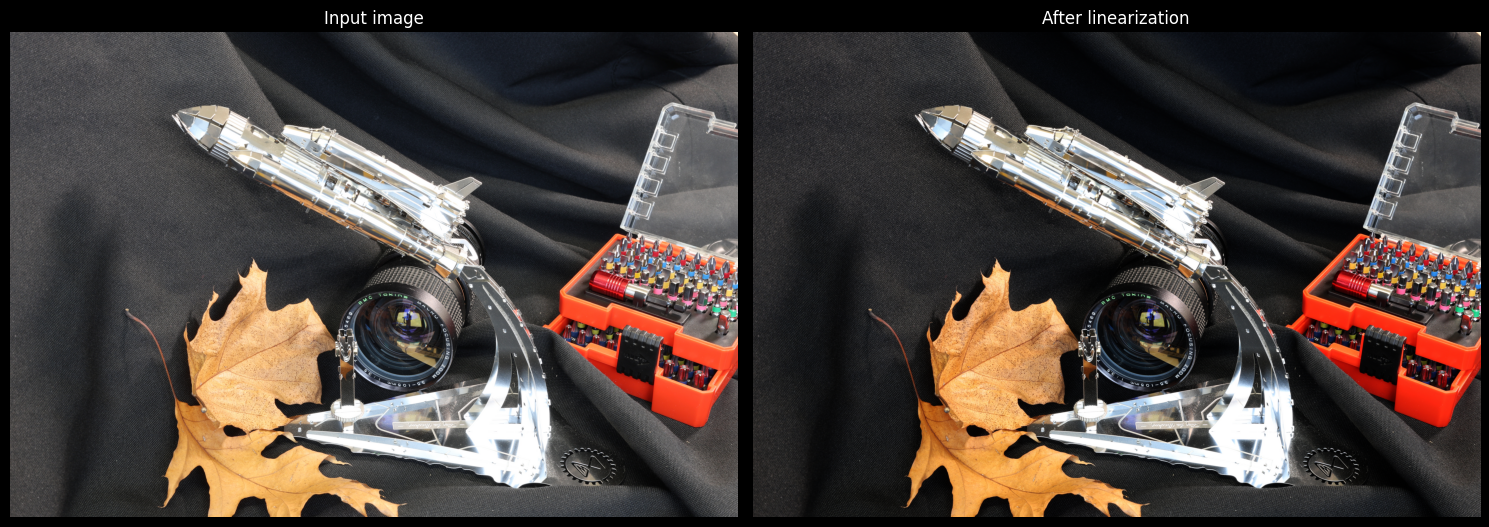

In [8]:
# Plot the image before and after linearization with gamma curve
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(normalized_images[4])
ax[0].set_title("Input image")
ax[0].axis('off')

ax[1].imshow(linearized_images_gamma[4])
ax[1].set_title("After linearization")
ax[1].axis('off')

plt.tight_layout()
plt.show()

## Second approach: Matrix Equation

In the second approach which is even stronger because we don't have any assumption, we can estimate the exact value that our curve assign to each luminosity value from 0 to 255.

If we look at a certain pixel position in two images which have same luminosity, but different exposures, we have:
$$ y_1 = f(L * E_1)$$
$$ y_2 = f(L * E_2)$$

If we invert function f, as consider the function g as the inversion of f, we have:
$$g(y_1) = L * E_1$$
$$g(y_2) = L * E_2$$

So  by dividing these two functions, we have:
$$\frac{g(y_1)}{g(y_2)} = \frac{E_1}{E_2}$$

Now, if we take logarithm, we can see:
$$log(\frac{g(y_1)}{g(y_2)}) = log(\frac{E_1}{E_2})$$
$$log(g(y_1)) - log(g(y_2)) = log(E_1) - log(E_2)$$

Using these equations, we can create a matrix to solve this matrix equation: A * x = b
So, to create the matrix A, for each sample, we have a row in our matrix that has 256 columns, then we can fill the columns based on the first part of our calculated equation: $$log(g(y_1)) - log(g(y_2))$$
Using this, we put +1 in the column related to y_1 and the value of -1 to the columns related to y_2. Also in order to have a smooth final curve, we add some other rows for smoothing the estimated curve at the end.
Also, we can fill the vector b, with the difference of logarithms of exposures.
Now that we have both A and b created, we can use np.linalg.lstsq to solve the matrix equation and find x.

In [9]:
def create_matrices(samples, exposures):
    A = []
    b = []

    # fill in the matrix with luminosity and exposure related values by looking at each sample
    for s in range(samples.shape[1]):
        sample = samples[:, s]

        # get the valid pixels in this sample (pixel position)
        valid_pixels_idx = np.where((sample >= LOWER_BOUND) & (sample <= UPPER_BOUND))[0]
        valid_pixels = sample[valid_pixels_idx]
        valid_exposures = exposures[valid_pixels_idx]

        # fill in the values for A and b
        for i in range(len(valid_pixels)):
            for j in range(i+1, len(valid_pixels)):

                luminosity_1 = int(valid_pixels[i])
                luminosity_2 = int(valid_pixels[j])
                d_log_exposures = np.log(valid_exposures[i]) - np.log(valid_exposures[j])

                sample_row = np.zeros(256)
                sample_row[luminosity_1] = 1.0
                sample_row[luminosity_2] = -1.0

                A.append(sample_row)
                b.append(d_log_exposures)

    # the estimated curve was too noisy so here I added rows for smoothing the curve by considering the fact that mostly the neighboring pixels should have nearly the same luminosities.
    for i in range(255):
        smoothing_row = np.zeros(256)
        smoothing_row[i] = 1.0
        smoothing_row[i + 1] = -1.0

        # we can consider a smoothing factor
        A.append(smoothing_row * 150.0)
        b.append(0.0)

    A = np.array(A)
    b = np.array(b)

    return A, b


In [10]:
# create A and b with defined function
A, b = create_matrices(samples, exposures)

In [11]:
# now, we can use our created matrix to solve the matrix equation and find the value of raw image for each pixel and the curve
log_luminosities, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

# as we took logarithm before for our calculations, now we should convert it back using exp
luminosities = np.exp(log_luminosities)

# to make the curve increasing all the time
luminosities = np.maximum.accumulate(luminosities)

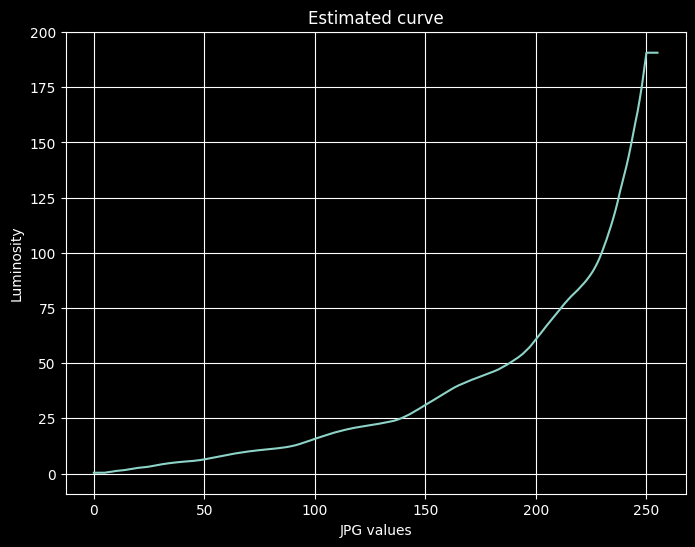

In [12]:
# plot our estimated curve

x = np.arange(256)

plt.figure(figsize=(8, 6))
plt.plot(x, luminosities)
plt.xlabel("JPG values")
plt.ylabel("Luminosity")
plt.title("Estimated curve")
plt.grid()
plt.show()

Now, we can use the estimated luminosities, and use inversion to find luminosities.

In [13]:
# Now that we have our estimation curve and the luminosity value for each of jpg values for 0 to 256, we can now place them to create our raw images
normalized_images = []
linearized_images = []
linearized_images_normalized = []

for i in range(len(images)):
    # first we need to convert values to integers to be able to use them as indices
    input_img = np.clip(images[i], 0, 255).astype(int)
    linearized_img = luminosities[input_img].astype(np.float64)
    linearized_images.append(linearized_img)

    # normalize it to be able to plot it in the next step
    linearized_img_normalized = linearized_images[i].astype(np.float64)
    a = np.percentile(linearized_img_normalized, 1)
    b = np.percentile(linearized_img_normalized, 99)
    linearized_img_normalized = np.clip((linearized_img_normalized - a) / (b - a), 0, 1)
    linearized_images_normalized.append(linearized_img_normalized)

    # also normalize the input images
    img_normalized = images[i].astype(np.float64) / 255.0
    img_normalized = np.clip(img_normalized, 0.0, 1.0)
    normalized_images.append(img_normalized)

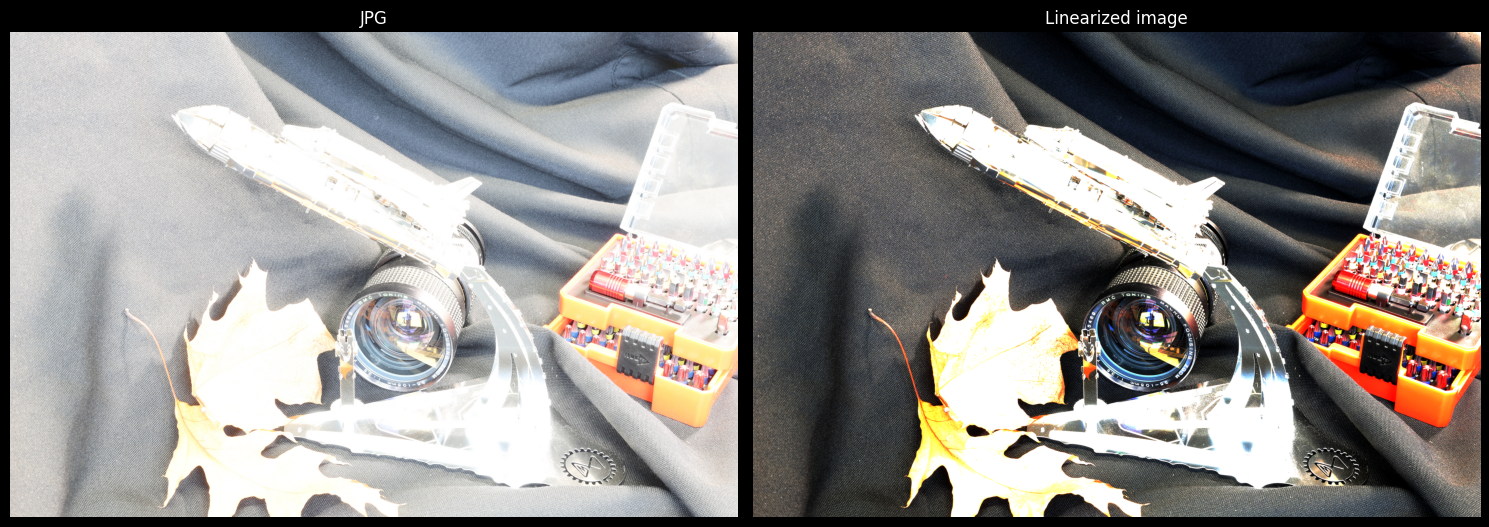

In [14]:
# Plot one of the images and comparing the result of JPJ and linearized image
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(normalized_images[1])
ax[0].set_title("JPG")
ax[0].axis('off')

ax[1].imshow(linearized_images_normalized[1])
ax[1].set_title("Linearized image")
ax[1].axis('off')

plt.tight_layout()
plt.show()

## Apply HDR Method

In [15]:
def apply_hdr(raw_images, exposures):
    """
    Apply hdr demosaicing algorithm to the raw image data
    This is the modified version of hdr method implemented in the previous group exercise

    Args:
        raw_images: linearized images
        exposures: exposure times

    Returns:
        hdr: the output after applying HDR method
    """
    # Load the brightest raw data (longest exposure)
    hdr = raw_images[0].copy()

    for k in range(1, len(raw_images)):

        # Load the next raw image
        i = raw_images[k]

        # Calculate the Exposure difference to first image and Multiply it by i
        ratio = exposures[0] / exposures[k]
        i_new =  i * ratio

        # Values in hdr which are above a threshold t get replaced by the corresponding values in i
        t = 0.8 * np.max(hdr)
        replacement_mask = (hdr > t)
        hdr[replacement_mask] = i_new[replacement_mask]

    return hdr


In [16]:
def apply_white_balance(image):
    """
    Applying white balance using Gray World algorithm
    assuming that the average color of the image is gray
    This is the modified version of this method implemented in the previous group exercise

    Args:
        image: image data

    Returns:
        data: image data after applying gray world white balance algorithm

    """

    # Get the mean value of the image
    mean = np.mean(image)

    # Get the mean value of each color channel
    r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]

    mean_r = np.mean(r)
    mean_g = np.mean(g)
    mean_b = np.mean(b)

    # applying white balance by multiplying values of each channel by mean_image / mean_channel
    r = r * (mean / mean_r)
    g = g * (mean / mean_g)
    b = b * (mean / mean_b)

    return np.dstack((r, g, b))


In [17]:
# Applying HDR method
hdr = apply_hdr(linearized_images, exposures)

# Now we can apply some techniques that also used in group part to get a better image at the end from our linearized image
white_balanced_hdr = apply_white_balance(hdr)

# normalize each channel
for i in range(3):
    channel = white_balanced_hdr[:,:, i]
    a = np.percentile(channel, 0.1)
    b = np.percentile(channel, 99.9)
    white_balanced_hdr[:,:,i] = (channel - a) / (b - a)

white_balanced_hdr = np.clip(white_balanced_hdr, 0, 1)


# Tone mapping
# Take logarithm of hdr and reduce dynamic range
epsilon = 1e-5  # to avoid from log(0)
log_hdr = np.log(white_balanced_hdr + epsilon)


# convert to correct range using percentiles
a = np.percentile(log_hdr, 1)
b = np.percentile(log_hdr, 99)
normalized_hdr = (log_hdr - a) / (b - a)
normalized_hdr = np.clip(normalized_hdr, 0.0, 1.0)

# Save the result image
image_to_save = (normalized_hdr * 255.0).astype(np.uint8)
image_bgr = cv2.cvtColor(image_to_save, cv2.COLOR_RGB2BGR)
cv2.imwrite("result.jpg", image_bgr, [int(cv2.IMWRITE_JPEG_QUALITY), 99])

True

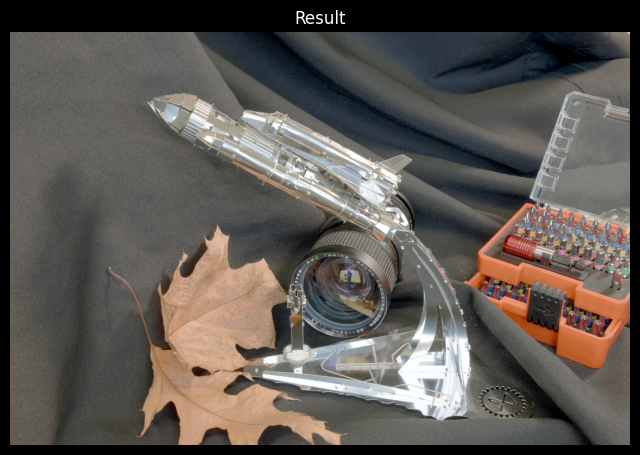

In [18]:
# Plot the final result:

plt.figure(figsize=(8, 8))
plt.imshow(image_to_save)
plt.axis('off')
plt.title("Result")
plt.show()